第１四分位数(Q1): 46.99
第３四分位数(Q3): 52.52
四分位範囲(IQR): 5.53
異常値の境界: 38.70 ~ 60.82
検出された異常値の数: 4


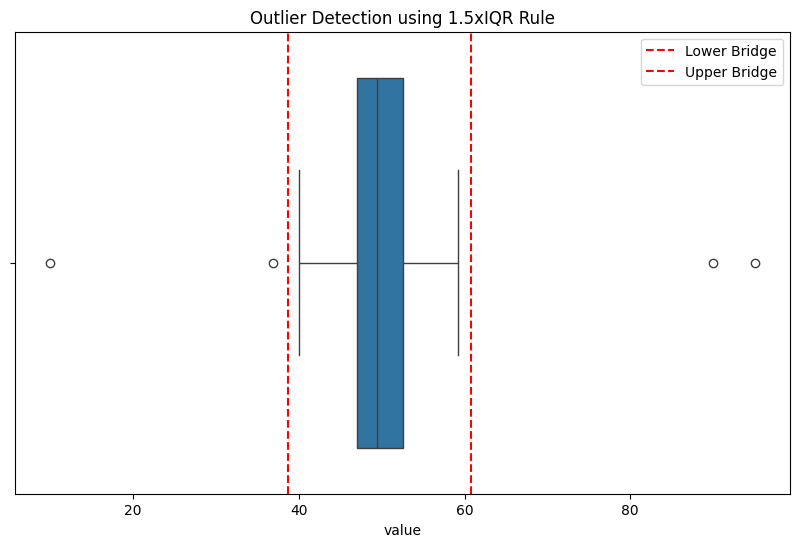

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. サンプルデータの作成（異常値を含む）
np.random.seed(42) # 結果を再現可能にするため
data = np.concatenate([np.random.normal(50, 5, 100), [10, 90, 95]])
df = pd.DataFrame(data, columns=['value'])

# 2. 四分位数の計算
q1 = df['value'].quantile(0.25)
q3 = df['value'].quantile(0.75)
iqr = q3 - q1

# 3. 異常値の境界を設定 (1.5xIQRルール)
lower_bridge = q1 - 1.5 * iqr
upper_bridge = q3 + 1.5 * iqr

# 4. 異常値の抽出
outliers = df[(df['value'] < lower_bridge) | (df['value'] > upper_bridge)]

print(f"第１四分位数(Q1): {q1:.2f}")
print(f"第３四分位数(Q3): {q3:.2f}")
print(f"四分位範囲(IQR): {iqr:.2f}")
print(f"異常値の境界: {lower_bridge:.2f} ~ {upper_bridge:.2f}")
print(f"検出された異常値の数: {len(outliers)}")

# 5. 可視化（箱ひげ図）
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['value'])
plt.title('Outlier Detection using 1.5xIQR Rule')
plt.axvline(lower_bridge, color='r', linestyle='--', label='Lower Bridge')
plt.axvline(upper_bridge, color='r', linestyle='--', label='Upper Bridge')
plt.legend()
plt.show()